# Environment catalogue

What MuJoCo Playground gives us to work with: which environments are
registered, which robot models they are built on, and how they are
configured by default.


In [54]:
import pandas as pd

from rl_locomotion.envs import registry as reg

pd.set_option("display.width", 200)
pd.set_option("display.max_colwidth", 60)


## The three suites - dm_control_suite, locomotion, and control_suite

Playground contains three families. Only `locomotion` is relevant to this
project!


In [55]:
envs = reg.envs_table()
print(f"{len(envs)} registered environments")
envs.groupby("suite").size().to_frame("n_envs")


54 registered environments


,n_envs
suite,
dm_control_suite,25
locomotion,19
manipulation,10


## Locomotion environments

Explanations of some columns:

- **`ctrl_dt` / `sim_dt`** - the policy acts every `ctrl_dt`, the physics
  integrates every `sim_dt`. Their ratio (`sim_steps_per_ctrl`) is how many
  physics steps each action costs.
- **`episode_s` / `episode length`** - episode length in simulated seconds rather than steps,
  which makes envs with different `ctrl_dt` comparable.
- **`has_domain_randomizer`** - whether Playground ships a randomizer for
  this env.


In [56]:
loco = reg.envs_table("locomotion")
loco[[
    "platform", "task", "ctrl_dt", "sim_dt", "sim_steps_per_ctrl",
    "episode_length", "episode_s", "has_domain_randomizer",
]]


,platform,task,ctrl_dt,sim_dt,sim_steps_per_ctrl,episode_length,episode_s,has_domain_randomizer
name,,,,,,,,
ApolloJoystickFlatTerrain,apollo,joystick,0.02,0.005,4,1000,20.0,False
BarkourJoystick,barkour,joystick,0.02,0.004,5,1000,20.0,False
BerkeleyHumanoidJoystickFlatTerrain,berkeley_humanoid,joystick,0.02,0.002,10,1000,20.0,True
BerkeleyHumanoidJoystickRoughTerrain,berkeley_humanoid,joystick,0.02,0.002,10,1000,20.0,True
G1JoystickFlatTerrain,g1,joystick,0.02,0.002,10,1000,20.0,True
G1JoystickRoughTerrain,g1,joystick,0.02,0.002,10,1000,20.0,True
Go1Footstand,go1,handstand,0.02,0.004,5,500,10.0,True
Go1Getup,go1,getup,0.02,0.004,5,300,6.0,True
Go1Handstand,go1,handstand,0.02,0.004,5,500,10.0,True


As we can see, there are 19 different locomotion environments, with different robots and different tasks. There are 9 different robots. Possible tasks are: joystick, handstand, getup, inplace_gait_tracking, joystick_gait_tracking.

## Robot models

Each environment is a *task* layered on a *robot model*. Several tasks
usually share one robot.

`n_xmls` counts the task scene files and helper, builder files Playground ships for that robot. 
Barkour has no local XML and loads its scene directly from
MuJoCo Menagerie, which is where all the robot meshes come from regardless!


In [57]:
# One line per environment — nothing truncated.
reg.show_models("locomotion")


,suite,n_envs,n_xmls,envs
platform,,,,
apollo,locomotion,1,2,ApolloJoystickFlatTerrain
barkour,locomotion,1,0,BarkourJoystick
berkeley_humanoid,locomotion,2,4,BerkeleyHumanoidJoystickFlatTerrain BerkeleyHumanoidJoystickRoughTerrain
g1,locomotion,2,6,G1JoystickFlatTerrain G1JoystickRoughTerrain
go1,locomotion,5,11,Go1Footstand Go1Getup Go1Handstand Go1JoystickFlatTerrain Go1JoystickRoughTerrain
h1,locomotion,2,2,H1InplaceGaitTracking H1JoystickGaitTracking
op3,locomotion,1,2,Op3Joystick
spot,locomotion,3,5,SpotFlatTerrainJoystick SpotGetup SpotJoystickGaitTracking
t1,locomotion,2,4,T1JoystickFlatTerrain T1JoystickRoughTerrain


### Every model, all suites


In [58]:
# Counts only, across all three suites.
reg.models_table()[["suite", "n_envs", "n_xmls"]]


,suite,n_envs,n_xmls
platform,,,
acrobot,dm_control_suite,2,1
ball_in_cup,dm_control_suite,1,1
cartpole,dm_control_suite,4,1
cheetah,dm_control_suite,1,1
finger,dm_control_suite,3,1
fish,dm_control_suite,1,1
hopper,dm_control_suite,2,1
humanoid,dm_control_suite,3,1
pendulum,dm_control_suite,1,1


### Scene files for one robot

The variants encode collision fidelity and terrain. `feetonly` models
collide only at the feet; `fullcollisions` is more accurate and slower.


In [59]:
go1 = next(m for m in reg.list_models("locomotion") if m.platform == "go1")
for xml in go1.xmls:
    print(xml)


go1_mjx.xml
go1_mjx_feetonly.xml
go1_mjx_fullcollisions.xml
scene_mjx_feetonly_bowl.xml
scene_mjx_feetonly_flat_terrain.xml
scene_mjx_feetonly_rough_terrain.xml
scene_mjx_feetonly_stairs.xml
scene_mjx_flat_terrain.xml
scene_mjx_fullcollisions_flat_terrain.xml
sensor_feet.xml
sensor_fullcollision.xml


## Default configuration for one environment


In [60]:
from mujoco_playground import registry as pg_registry

cfg = pg_registry.get_default_config("Go1JoystickFlatTerrain")
print(cfg)


Kd: 0.5
Kp: 35.0
action_repeat: 1
action_scale: 0.5
command_config:
  a:
  - 1.5
  - 0.8
  - 1.2
  b:
  - 0.9
  - 0.25
  - 0.5
ctrl_dt: 0.02
episode_length: 1000
history_len: 1
impl: warp
naconmax: 32768
njmax: 40
noise_config:
  level: 1.0
  scales:
    gravity: 0.05
    gyro: 0.2
    joint_pos: 0.03
    joint_vel: 1.5
    linvel: 0.1
pert_config:
  enable: false
  kick_durations:
  - 0.05
  - 0.2
  kick_wait_times:
  - 1.0
  - 3.0
  velocity_kick:
  - 0.0
  - 3.0
reward_config:
  max_foot_height: 0.1
  scales:
    action_rate: -0.01
    ang_vel_xy: -0.05
    dof_pos_limits: -1.0
    energy: -0.001
    feet_air_time: 0.1
    feet_clearance: -2.0
    feet_height: -0.2
    feet_slip: -0.1
    lin_vel_z: -0.5
    orientation: -5.0
    pose: 0.5
    stand_still: -1.0
    termination: -1.0
    torques: -0.0002
    tracking_ang_vel: 0.5
    tracking_lin_vel: 1.0
  tracking_sigma: 0.25
sim_dt: 0.004
soft_joint_pos_limit_factor: 0.95



### Reward terms

The reward is a weighted sum of these. Reward shaping means changing these
scales!


In [61]:
scales = cfg.reward_config.scales
pd.Series(dict(scales), name="scale").sort_values(ascending=False).to_frame()


,scale
tracking_lin_vel,1.0000
pose,0.5000
tracking_ang_vel,0.5000
feet_air_time,0.1000
torques,-0.0002
energy,-0.0010
action_rate,-0.0100
ang_vel_xy,-0.0500
feet_slip,-0.1000
feet_height,-0.2000


## Model dimensions


In [62]:
print("menagerie present:", reg.menagerie_available())


menagerie present: True


In [63]:
if reg.menagerie_available():
    d = reg.describe_env("Go1JoystickFlatTerrain")
    for k in ["observation_size", "action_size", "nq", "nv", "nu", "nbody"]:
        print(f"{k:>18}: {d[k]}")
    print(f"{'actuators':>18}: {', '.join(d['actuators'])}")
    print(f"{'sensors':>18}: {', '.join(d['sensors'])}")
else:
    print("Menagerie not downloaded — run reg.ensure_menagerie() above first.")


  observation_size: {'privileged_state': (123,), 'state': (48,)}
       action_size: 12
                nq: 19
                nv: 18
                nu: 12
             nbody: 14
         actuators: FR_hip, FR_thigh, FR_calf, FL_hip, FL_thigh, FL_calf, RR_hip, RR_thigh, RR_calf, RL_hip, RL_thigh, RL_calf
           sensors: gyro, local_linvel, accelerometer, position, upvector, forwardvector, global_linvel, global_angvel, orientation, FR_global_linvel, FL_global_linvel, RR_global_linvel, RL_global_linvel, FR_pos, FL_pos, RR_pos, RL_pos, FR_floor_found, FL_floor_found, RL_floor_found, RR_floor_found


---

# Seeing the robots




In [64]:
import os

os.environ.setdefault("MUJOCO_GL", "glfw")  # laptop; use "egl" on the pod

from mujoco_playground import registry as pg_registry
from rl_locomotion.eval import render as rr
from rl_locomotion.eval.rollout import rollout, random_policy

print("backend:", rr.configure_backend())


backend: glfw


## A rollout, as video

No policy has been trained yet, so there are only two things to watch:

- **zero action** - the robot holds its default pose and settles under
  gravity.
- **random action** - uniform noise. It falls over, quickly. Expected.


In [65]:
env = pg_registry.load("Go1JoystickFlatTerrain")

ro_zero = rollout(env, policy=None, n_steps=100, seed=0,
                  env_name="Go1JoystickFlatTerrain")
ro_zero.summary()


{'env': 'Go1JoystickFlatTerrain',
 'steps': 100,
 'duration_s': 2.0,
 'total_reward': 1.42,
 'mean_reward': 0.0142,
 'terminated_early': False}

In [66]:
frames = rr.render_rollout(env, ro_zero, height=240, width=320)
rr.show_video(frames, fps=rr.video_fps(env))


100%|██████████| 101/101 [00:01<00:00, 84.92it/s]


This browser does not support the video tag.


In [37]:
ro_rand = rollout(env, policy=random_policy(env.action_size), n_steps=100,
                  seed=0, env_name="Go1JoystickFlatTerrain")
ro_rand.summary()


{'env': 'Go1JoystickFlatTerrain',
 'steps': 37,
 'duration_s': 0.74,
 'total_reward': 0.0,
 'mean_reward': 0.0,
 'terminated_early': True}

In [67]:
frames = rr.render_rollout(env, ro_rand, height=240, width=320)
rr.show_video(frames, fps=rr.video_fps(env))


100%|██████████| 38/38 [00:00<00:00, 72.65it/s]


This browser does not support the video tag.



Note the summaries above: the random rollout terminates early **and**
reports a total reward of exactly `0.0`. This is because Go1's joystick task computes reward as

```python
reward = clip(sum(terms) * dt, 0.0, 10000.0)
```
so once the penalties outweigh the positive terms, the total floors at zero
and stays there.
This clipping applies to 11 of the 15 locomotion tasks. G1 and Apollo
joystick, `h1/inplace_gait_tracking` and `spot/joystick_gait_tracking` do
**not** clip and can report negative returns — so a return of zero means
different things depending on the robot.


In [68]:
ro_rand.metrics_frame().filter(like="reward/").describe().T[["mean", "min", "max"]]


,mean,min,max
reward/action_rate,-0.076612,-1.640685e-01,-0.026772
reward/ang_vel_xy,-1.799635,-8.832199e+00,-0.013817
reward/dof_pos_limits,0.000000,-0.000000e+00,-0.000000
reward/energy,-0.807051,-1.832908e+00,-0.235931
reward/feet_air_time,-0.002432,-1.200000e-02,0.002000
reward/feet_clearance,-0.731249,-1.838933e+00,-0.252129
reward/feet_height,-0.048800,-2.198052e-01,-0.000000
reward/feet_slip,-0.312232,-1.496289e+00,-0.000000
reward/lin_vel_z,-0.076646,-5.528339e-01,-0.000008
reward/orientation,-1.303023,-4.999225e+00,-0.000318


---

# Figures of the robots



(900, 1200, 3)


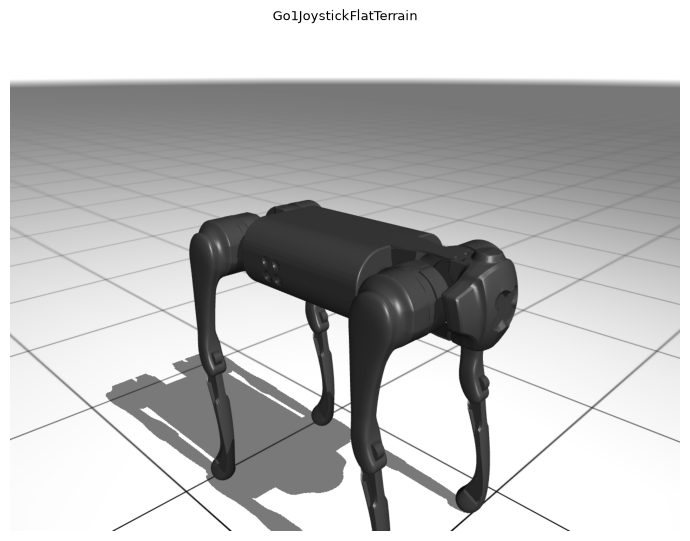

In [69]:
from rl_locomotion.eval import figures as fig

env = pg_registry.load("Go1JoystickFlatTerrain")
shot = fig.hero_shot(env, width=1200, height=900)
print(shot.shape)
rr.gallery([shot], ["Go1JoystickFlatTerrain"], ncols=1, figsize_per_tile=7);


## Choosing the camera

Lower `zoom` fills more of the frame:


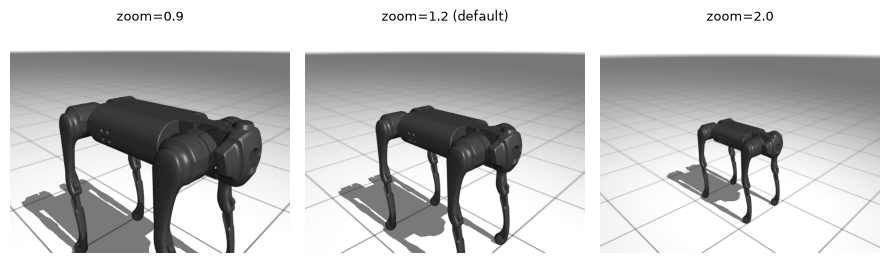

In [70]:
shots = [fig.hero_shot(env, width=600, height=480, zoom=z) for z in (0.9, 1.2, 2.0)]
rr.gallery(shots, ["zoom=0.9", "zoom=1.2 (default)", "zoom=2.0"], ncols=3);


### Several angles at once



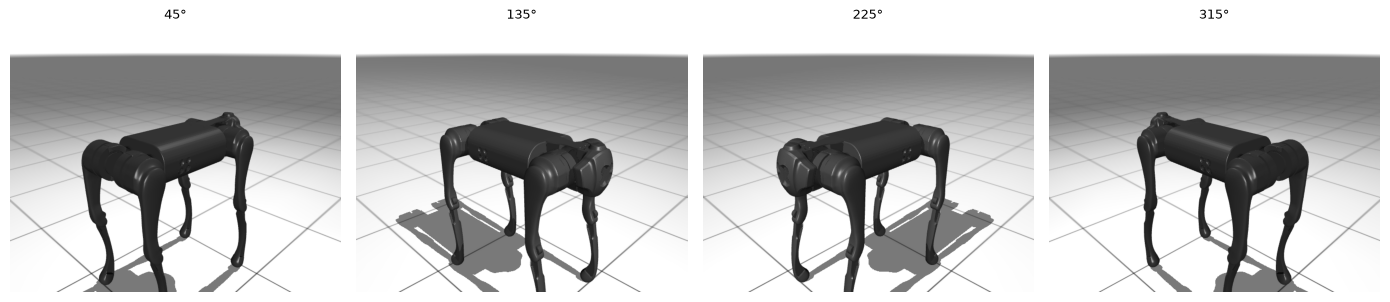

In [71]:
views = fig.orbit(env, n_views=4, width=700, height=560)
rr.gallery(views, [f"{45 + i * 90}°" for i in range(4)], ncols=4,
           figsize_per_tile=3.5);


## All nine robots in one figure




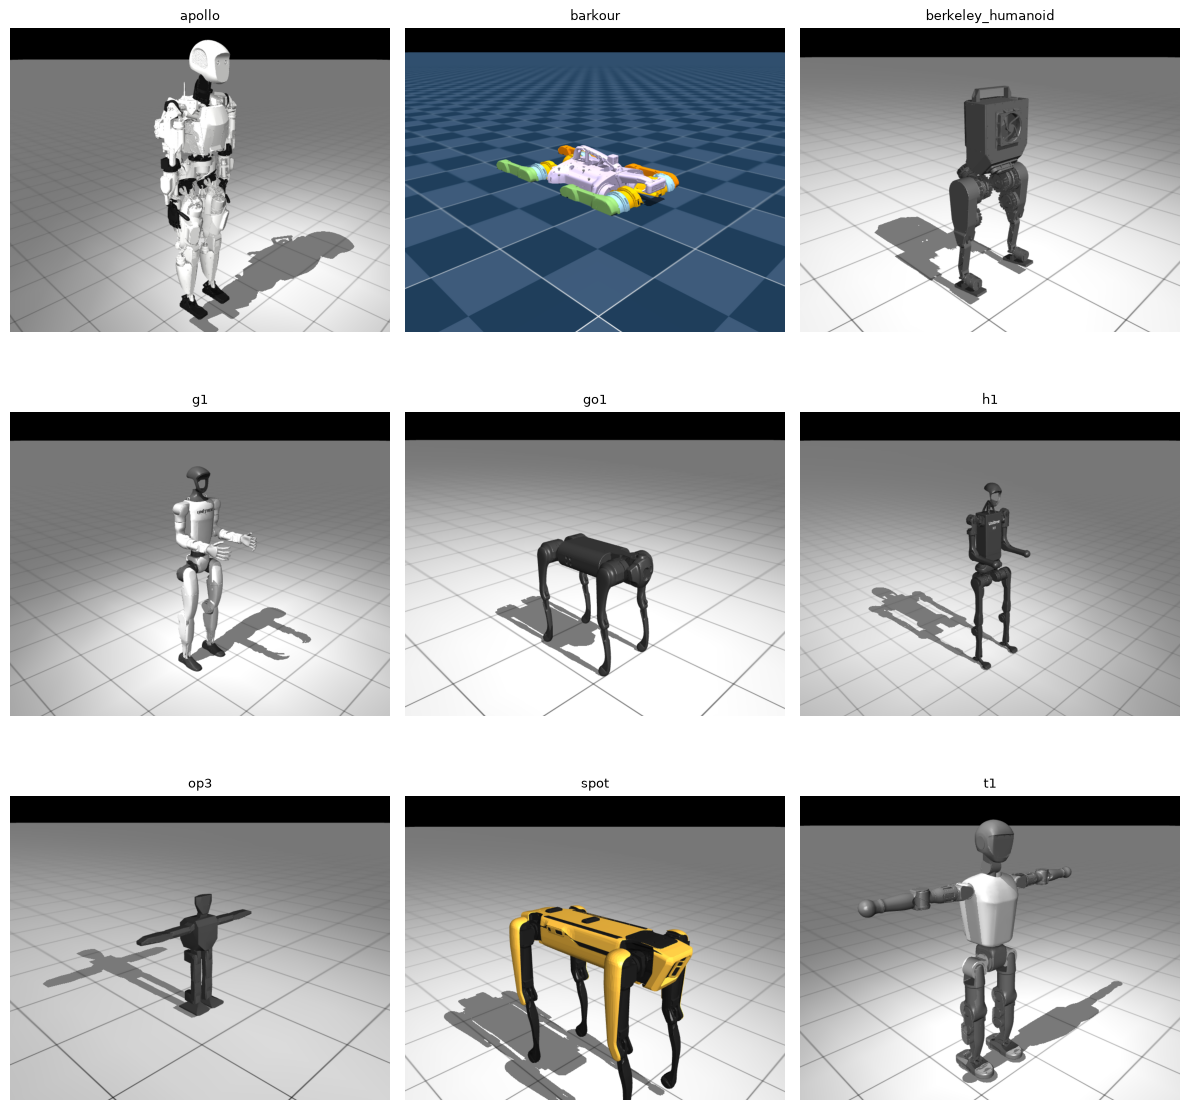

In [75]:
fig.robot_lineup(zoom=2.0, skybox=False, reflections=False);


## Finding an angle by hand


```bash
# macOS needs mjpython — the viewer must own the main thread
mjpython scripts/view_model.py Go1JoystickFlatTerrain

mjpython scripts/view_model.py --list   # see the env names
```


